In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data2.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [7]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [9]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [10]:
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [23]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [24]:
grouped_df.head(10)

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055
5,2018-01-10,3653
6,2018-01-11,3176
7,2018-01-12,3092
8,2018-01-13,3294
9,2018-01-14,3228


Нарисуйте график продаж у `grouped_df`

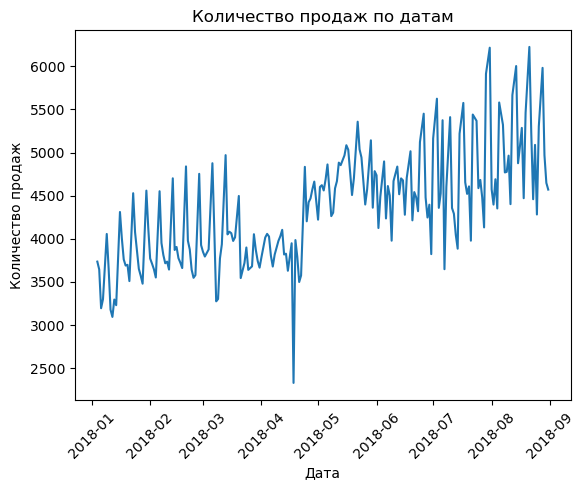

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.title('Количество продаж по датам')
plt.xticks(rotation=45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

На графике показана динамика количества продаж с января по сентябрь 2018 года.
Наблюдается устойчивый рост продаж: значения увеличиваются от начала периода к его концу, что говорит о положительном тренде.
При этом на графике изображены регулярные повторяющиеся колебания.
Также присутствует единичное резкое отклонение от общего тренда в апреле 2018 года, который может быть связан с техническими сбоями в работе склада или внешними факторами и требует дополнительного анализа.
Разброс значений увеличивается к концу периода, колебания становятся более выраженными, что может говорить о росте как среднего уровня продаж, и их неустойчивости.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [64]:
Q1 = df['Количество'].quantile(0.25)
Q3 = df['Количество'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
upper_bound

np.float64(8.5)

In [65]:
outliers = df[df['Количество'] > upper_bound]
max_outlier_row = outliers.loc[outliers['Количество'].idxmax()]
max_outlier_row

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

28 июня 2018 года максимальное количество продаж 200.

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [44]:
df[
    (df['Дата'].dt.weekday == 2) &
    (df['Дата'].dt.month.isin([6, 7, 8])) &
    (df['Склад'] == 3)
].groupby('Номенклатура')['Количество'].sum().idxmax()

'product_1'

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [66]:
import pandas as pd
weather = pd.read_csv("weather_astana.csv")

In [75]:
weather_df = weather.groupby('Дата')['T'].mean().reset_index()

In [76]:
weather_df.head()

,Дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [77]:
merged_df = grouped_df.merge(
    weather_df,
    on='Дата',
    how='inner'
)

In [97]:
merged_df.head()

,Дата,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


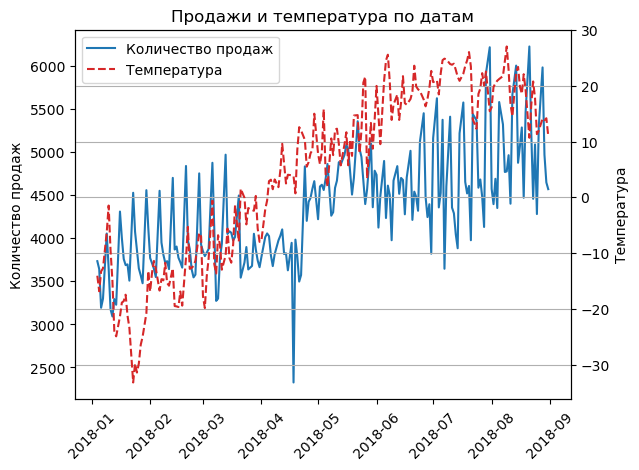

In [95]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
ax1.plot(merged_df['Дата'], merged_df['Количество'], label='Количество продаж')
ax1.set_ylabel('Количество продаж')
ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['T'], linestyle='--', label='Температура', color='tab:red')
ax2.set_ylabel('Температура')
plt.title('Продажи и температура по датам')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2)
ax1.tick_params(axis='x', rotation=45)
plt.grid(True)
plt.show()

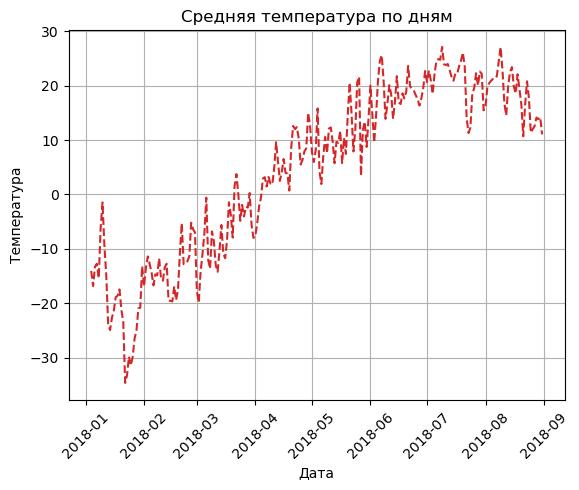

In [96]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(weather_df['Дата'], weather_df['T'],  linestyle='--', color='tab:red')
plt.title('Средняя температура по дням')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()